<a href="https://colab.research.google.com/github/Roi-flores13/fnn_sport_forecast/blob/main/Practica_ffnn_sports_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Lambda
import tensorflow as tf

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objects as go

In [2]:
API_KEY   = '4875fc829b5650e07a89e3b0304ba7c0'
TEAM_ID   = 2283   # Chivas de Guadalajara
LEAGUE_ID = 262    # Liga MX
SEASONS   = [2022, 2023, 2024]

HEADERS  = {'x-apisports-key': API_KEY}
BASE_URL = 'https://v3.football.api-sports.io'


def fetch_fixtures(team_id, league_id, season):
    r = requests.get(
        f'{BASE_URL}/fixtures',
        headers=HEADERS,
        params={'team': team_id, 'league': league_id, 'season': season, 'status': 'FT'}
    )
    r.raise_for_status()
    data = r.json()
    if data.get('errors'):
        raise ValueError(data['errors'])
    return data['response']


def parse_fixtures(fixtures, team_id):
    rows = []
    for f in fixtures:
        fix     = f['fixture']
        teams   = f['teams']
        goals   = f['goals']
        is_home = teams['home']['id'] == team_id

        ch_g    = goals['home'] if is_home else goals['away']
        opp_g   = goals['away'] if is_home else goals['home']
        rival   = teams['away']['name'] if is_home else teams['home']['name']

        if ch_g is not None and opp_g is not None:
            resultado = 'W' if ch_g > opp_g else ('L' if ch_g < opp_g else 'D')
        else:
            resultado = None

        rows.append({
            'fixture_id':  fix['id'],
            'fecha':       fix['date'],
            'local':       is_home,
            'rival':       rival,
            'goles_ch':    ch_g,
            'goles_rival': opp_g,
            'resultado':   resultado,
            'asistencia':  fix.get('status', {}).get('attendance'),
        })
    return pd.DataFrame(rows)


dfs = []
for s in SEASONS:
    print(f'Temporada {s}...', end=' ')
    raw = fetch_fixtures(TEAM_ID, LEAGUE_ID, s)
    df  = parse_fixtures(raw, TEAM_ID)
    df['temporada'] = s
    dfs.append(df)
    print(f'{len(df)} partidos')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(df_raw)} registros')
df_raw.head()

Temporada 2022... 37 partidos
Temporada 2023... 34 partidos
Temporada 2024... 36 partidos

Total: 107 registros


,fixture_id,fecha,local,rival,goles_ch,goles_rival,resultado,asistencia,temporada
0,864098,2022-07-03T02:05:00+00:00,False,Club America,0,0,D,None,2022
1,864109,2022-07-10T17:00:00+00:00,False,Toluca,2,3,L,None,2022
2,864115,2022-07-16T22:00:00+00:00,True,Cruz Azul,3,2,W,None,2022
3,864127,2022-07-24T02:05:00+00:00,False,Tigres UANL,0,2,L,None,2022
4,864130,2022-07-27T00:00:00+00:00,True,Club Tijuana,1,2,L,None,2022


In [3]:
df = df_raw.copy()

df['fecha'] = pd.to_datetime(df['fecha'], utc=True).dt.tz_localize(None)
df = df.sort_values('fecha').reset_index(drop=True)
df['jornada'] = df.index + 1

df['goles_rival'] = pd.to_numeric(df['goles_rival'], errors='coerce')

# Features de contexto
df['mes']           = df['fecha'].dt.month
df['dia_semana']    = df['fecha'].dt.dayofweek
df['es_local']      = df['local'].astype(int)
df['resultado_cod'] = df['resultado'].map({'W': 1, 'D': 0, 'L': -1})
df['resultado_lag1'] = df['resultado_cod'].shift(1).fillna(0)

print(df[['jornada','fecha','rival','asistencia','es_local','resultado']].head(10))

   jornada               fecha               rival asistencia  es_local  \
0        1 2022-07-03 02:05:00        Club America       None         0   
1        2 2022-07-10 17:00:00              Toluca       None         0   
2        3 2022-07-16 22:00:00           Cruz Azul       None         1   
3        4 2022-07-24 02:05:00         Tigres UANL       None         0   
4        5 2022-07-27 00:00:00        Club Tijuana       None         1   
5        6 2022-08-01 00:05:00       Santos Laguna       None         0   
6        7 2022-08-05 02:00:00      Club Queretaro       None         1   
7        8 2022-08-14 02:05:00  Guadalajara Chivas       None         0   
8        9 2022-08-17 00:00:00           FC Juarez       None         1   
9       10 2022-08-21 00:05:00              Puebla       None         1   

  resultado  
0         D  
1         L  
2         W  
3         L  
4         L  
5         L  
6         W  
7         D  
8         L  
9         D  


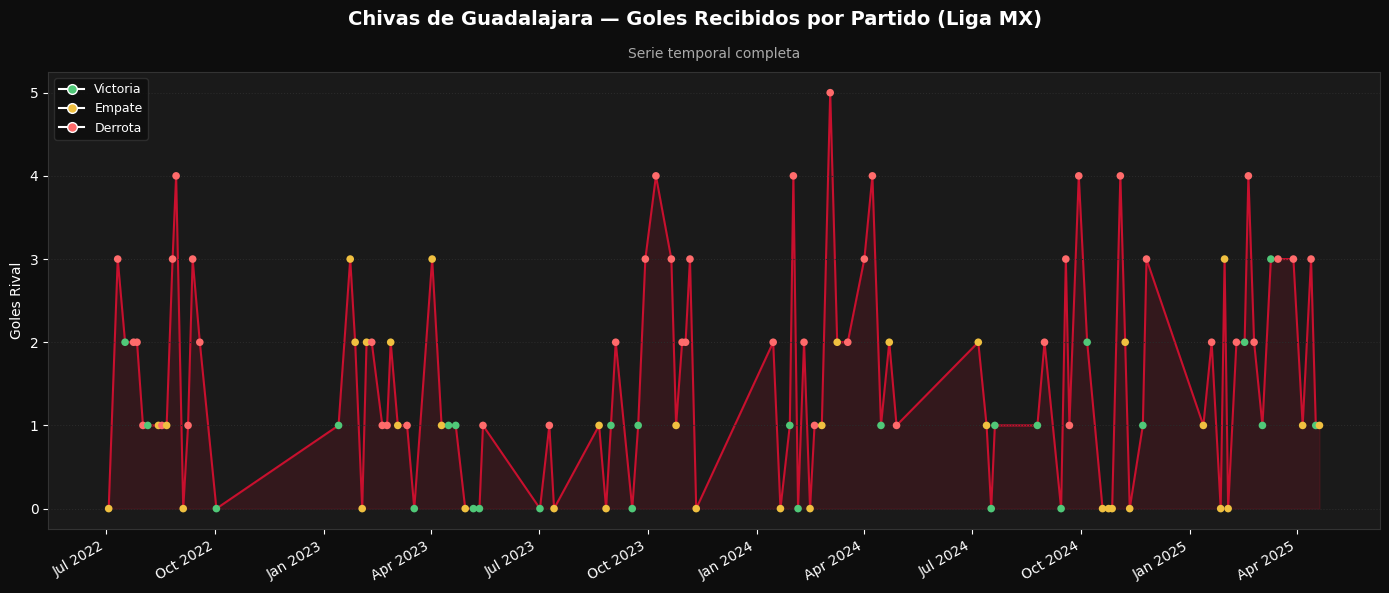

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6), facecolor='#0D0D0D')
fig.suptitle('Chivas de Guadalajara — Goles Recibidos por Partido (Liga MX)',
             color='white', fontsize=14, fontweight='bold', y=0.98)

COLOR_MAP = {'W': '#50C878', 'D': '#F0C040', 'L': '#ff6b6b'}
colors = df['resultado'].map(COLOR_MAP).fillna('#888888')

# Configuración del fondo del área de trazado
ax.set_facecolor('#1A1A1A')

# Dibujo de la serie y el área sombreada
ax.plot(df['fecha'], df['goles_rival'], color='#C8102E', lw=1.5, zorder=1)
ax.fill_between(df['fecha'], df['goles_rival'], alpha=0.15, color='#C8102E')

# Puntos de datos coloreados por resultado
ax.scatter(df['fecha'], df['goles_rival'], c=colors, s=30, zorder=3, edgecolors='none')

ax.set_ylabel('Goles Rival', color='white')
ax.tick_params(colors='white')

# Formato de fechas en el eje X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Eliminar bordes (spines) y añadir rejilla horizontal
for sp in ax.spines.values():
    sp.set_color('#333')
ax.grid(axis='y', color='#2A2A2A', lw=0.8, linestyle=':')

# Creación de la leyenda personalizada
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#50C878', label='Victoria', markersize=7),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F0C040', label='Empate', markersize=7),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff6b6b', label='Derrota', markersize=7),
]
ax.legend(handles=legend_elems, facecolor='#0D0D0D', edgecolor='#333', labelcolor='white', fontsize=9, loc='upper left')

ax.set_title('Serie temporal completa', color='#aaa', fontsize=10, pad=10)

plt.tight_layout()
plt.show()

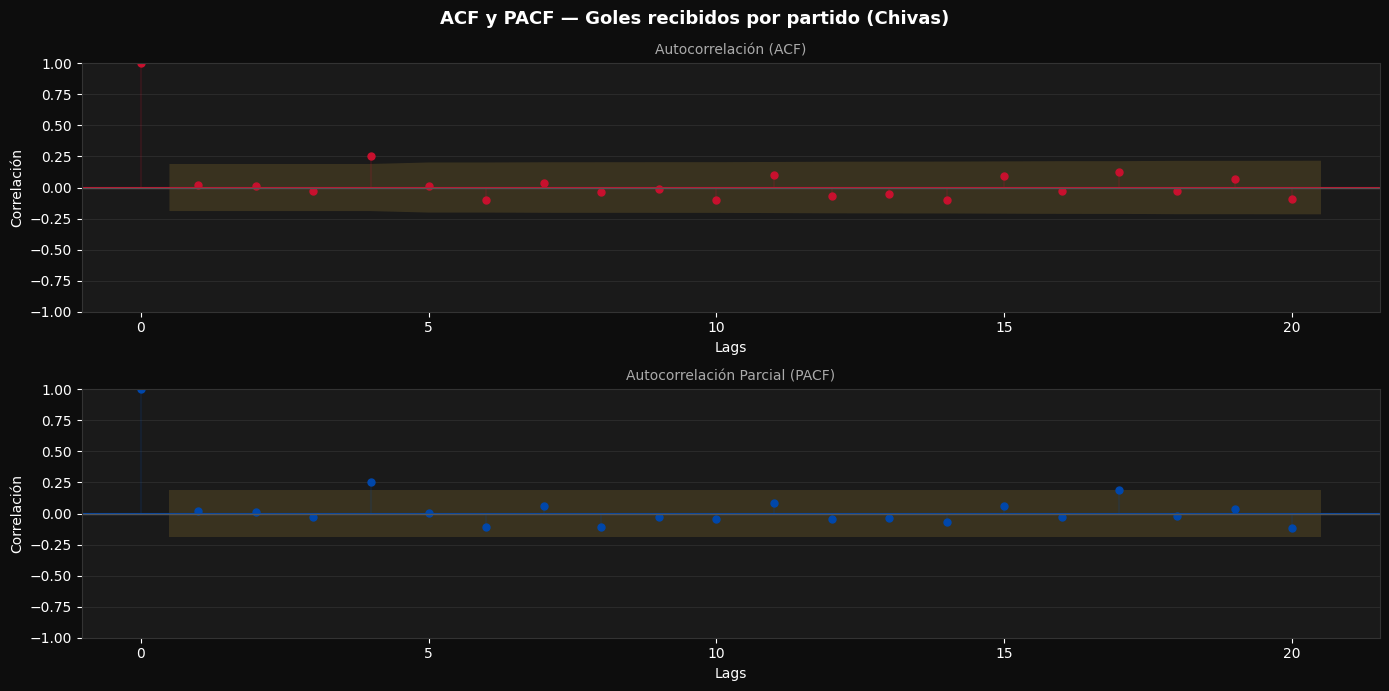

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie = df['goles_rival'].dropna().values

fig, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor='#0D0D0D')
fig.suptitle('ACF y PACF — Goles recibidos por partido (Chivas)',
             color='white', fontsize=13, fontweight='bold')

plot_acf(serie, lags=20, ax=axes[0],
         color='#C8102E', vlines_kwargs={'colors': '#C8102E'})
axes[0].set_title('Autocorrelación (ACF)', color='#aaa', fontsize=10)

plot_pacf(serie, lags=20, ax=axes[1], method='ywm',
          color='#0047AB', vlines_kwargs={'colors': '#0047AB'})
axes[1].set_title('Autocorrelación Parcial (PACF)', color='#aaa', fontsize=10)

for ax in axes:
    ax.set_facecolor('#1A1A1A')
    ax.tick_params(colors='white')
    ax.set_xlabel('Lags', color='white')
    ax.set_ylabel('Correlación', color='white')
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.grid(axis='y', color='#2A2A2A', lw=0.8)
    # Banda de confianza
    for col in ax.collections:
        col.set_alpha(0.15)
        col.set_facecolor('#F0C040')
    # Línea de cero
    ax.axhline(0, color='#555', lw=1)

plt.tight_layout()
plt.show()

In [6]:
TARGET_COL   = 'goles_rival'
WINDOW       = 3

# Array 2D con solo el target para respetar tu esquema univariado
serie_tiempo = df[TARGET_COL].dropna().values.reshape(-1, 1)

# Split 80/20 ANTES de escalar
train_size   = int(len(serie_tiempo) * 0.8)
train_data   = serie_tiempo[:train_size]
test_data    = serie_tiempo[train_size:]

# Scaler fit SOLO en train
scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

# Ventanas deslizantes
def crear_ventanas(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

X_train, y_train = crear_ventanas(train_scaled, WINDOW)
X_test,  y_test  = crear_ventanas(test_scaled,  WINDOW)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Ventana : {WINDOW} partidos')
print(f'Entrada FFNN → {X_train.shape[1]} neuronas')

X_train : (82, 3)
X_test  : (19, 3)
Ventana : 3 partidos
Entrada FFNN → 3 neuronas


In [18]:
model = Sequential([
    # Capa 1: input_dim DEBE coincidir con el window_size
    Dense(64, activation='relu', input_dim=WINDOW, name='Hidden1'),

    # Capa de Salida: 1 neurona Funcion de act LINEAL
    Dense(1, activation="relu", name='Forecast')
])
model.summary()

# Usamos el optimizador Adam y MSE
optimizador = Adam(learning_rate=0.005)
model.compile(optimizer=optimizador, loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=20,           # Cantidad de veces que verá el dataset completo
    batch_size=32,        # Actualiza los pesos cada 8 ventanas
    validation_data=(X_train, y_train), # Evaluamos en datos que no ha visto
    verbose=1            # 0 para no mostrar info
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Forecast (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - loss: 0.0876 - val_loss: 0.0643
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0680 - val_loss: 0.0700
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0689 - val_loss: 0.0632
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0641 - val_loss: 0.0595
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0596 - val_loss: 0.0594
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0596 - val_loss: 0.0590
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0587 - val_loss: 0.0578
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0580 - val_loss: 0.0577
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0580 - val_loss: 0.0575
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0573 - val_loss: 0.0567
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0565 - val_loss: 0.0566
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0571 - val_loss: 0.0568


In [20]:
y_pred_scaled = model.predict(X_test, verbose=0)

y_pred       = np.round(scaler.inverse_transform(y_pred_scaled)).astype(int) # se redondea solo para que nos de valores enteros
y_test_real  = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_real = scaler.inverse_transform(y_train.reshape(-1, 1))

mae  = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print(f"MAE  (Error Absoluto Medio):            {mae:.2f} goles")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} goles")

fechas_train = df['fecha'].iloc[WINDOW:train_size]
fechas_test  = df['fecha'].iloc[train_size + WINDOW:]

fig = go.Figure()

# Serie de entrenamiento (real)
fig.add_trace(go.Scatter(
    x=fechas_train,
    y=y_train_real.flatten(),
    mode='lines',
    name='Train (real)',
    line=dict(color='#bdc3c7', width=1.5)
))

# Test real
fig.add_trace(go.Scatter(
    x=fechas_test,
    y=y_test_real.flatten(),
    mode='lines+markers',
    name='Test (real)',
    line=dict(color='#2ca02c', width=2.5),
    marker=dict(size=6)
))

# Forecast FFNN
fig.add_trace(go.Scatter(
    x=fechas_test,
    y=y_pred.flatten(),
    mode='lines+markers',
    name='Pronóstico FFNN',
    line=dict(color='#C8102E', dash='dot', width=2.5),
    marker=dict(size=6)
))

fecha_corte = df['fecha'].iloc[train_size].strftime('%Y-%m-%d')

fig.add_shape(
    type='line',
    x0=fecha_corte, x1=fecha_corte,
    y0=0, y1=1,
    xref='x', yref='paper',
    line=dict(color='#F0C040', width=2, dash='dash')
)

fig.add_annotation(
    x=fecha_corte,
    y=1,
    xref='x', yref='paper',
    text='Train | Test',
    showarrow=False,
    font=dict(color='#F0C040'),
    xanchor='left',
    yanchor='top'
)

fig.update_layout(
    title='Forecast FFNN — Goles recibidos por partido (Chivas)',
    xaxis_title='Fecha',
    yaxis_title='Goles recibidos',
    plot_bgcolor='#1A1A1A',
    paper_bgcolor='#0D0D0D',
    font=dict(color='white'),
    xaxis=dict(gridcolor='#2A2A2A', tickformat='%b %Y', type='date'),
    yaxis=dict(gridcolor='#2A2A2A', tickformat='.1f'),
    legend=dict(
        x=0.01, y=0.99,
        bgcolor='rgba(30,30,30,0.8)',
        bordercolor='#444',
        borderwidth=1
    ),
    annotations=[dict(
        x=0.99, y=0.05,
        xref='paper', yref='paper',
        text=f'MAE: {mae:.2f} goles  |  RMSE: {rmse:.2f} goles',
        showarrow=False,
        font=dict(color='#F0C040', size=12),
        bgcolor='rgba(30,30,30,0.8)',
        bordercolor='#444',
        borderpad=6
    )]
)

fig.show()

MAE  (Error Absoluto Medio):            0.89 goles
RMSE (Raíz del Error Cuadrático Medio): 1.24 goles
